# The bar chart plot type (`make_bar`, `type="bar"`)

This notebook showcases `make_bar()`, a standard **bar chart**: one bar per distinct
value, sized by how often that value occurred, with **no binning**. Unlike the draft
demos in this folder, `make_bar` is already **integrated into the package** — it lives
in `symbulate/plot.py` and is wired into `.plot()`, so `RV(...).sim(...).plot(type="bar")`
works directly.

Where the bar chart fits: in the default plot lookup table (DECISIONS.md, "Decision:
Default Plot Lookup Table") it is an **alternative** — never the automatic default — for
the 1D discrete-ish and 1D categorical/string configurations, so it shows up in the
suggestion message as `type="bar"`. It is the categorical counterpart of the histogram:
where a histogram bins a continuous axis, a bar chart gives every distinct value its own
labeled bar, which is what you want for categorical outcomes (`"H"`/`"T"`) and for
discrete numbers whose exact values matter.

**How to run:** open this notebook from the `team/new_graphics/new_graphics_demos/`
folder using the `symbulate` conda environment, then Run All.

**What to look for:**
- One bar per distinct value; values are **never binned**
- Distinct values placed as evenly spaced categories in sorted order (numbers
  ascending, strings alphabetical), each labeled with the value itself
- Solid bars with thin white edges (like the histogram) so adjacent bars stay distinct
- x-axis always reads "Value"; y-axis and title read "Relative Frequency" / "Bar Chart"
  (or "Count" / "Bar Chart" when `normalize=False`)
- Light horizontal reference grid behind the bars; no top/right spines
- With `color` supplied from `get_next_color(ax)`, overlays take distinct Okabe-Ito hues
- A single bar chart gets no legend; a second one on the same axes adds an
  auto-numbered legend ("Variable 1", "Variable 2", ...)

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

# make_bar is integrated into the package, so we import it straight from
# symbulate.plot -- no draft-module path hack needed. Importing symbulate also
# applies symbulate.mplstyle (Okabe-Ito cycle, grid, spines, fonts), so the
# plots below already carry the package style.
from symbulate import RV, BoxModel, Binomial, Poisson
from symbulate.plot import make_bar, get_next_color, BAR_ALPHA

SKY_BLUE = "#56B4E9"  # Okabe-Ito, the package's default single-plot color
print(f"BAR_ALPHA = {BAR_ALPHA}")

BAR_ALPHA = 0.65


## 1. The core use case: categorical data

A bar chart is the natural view of categorical outcomes. `make_bar` counts each distinct
value and draws one bar per category, in sorted (here alphabetical) order. With
`normalize=True` (the default) the bar heights are relative frequencies that sum to 1.

The caller supplies the axes and a color — exactly how `RVResults.plot()` calls every
plot helper. Here we pass the Okabe-Ito sky blue directly.

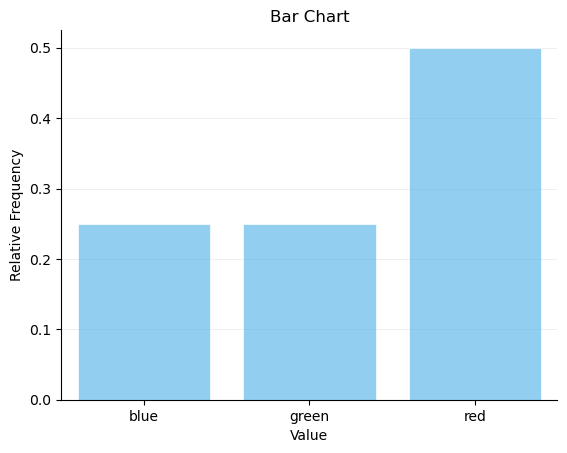

In [2]:
colors = np.array(["red", "green", "blue", "red", "red", "green", "blue", "red"])

ax = plt.gca()
make_bar(colors, ax, SKY_BLUE)
plt.show()  # three bars (blue, green, red), heights summing to 1

## 2. Counts vs. relative frequency

`normalize=False` switches the bar heights to raw counts and the y-axis label to
"Count" (the title stays "Bar Chart").

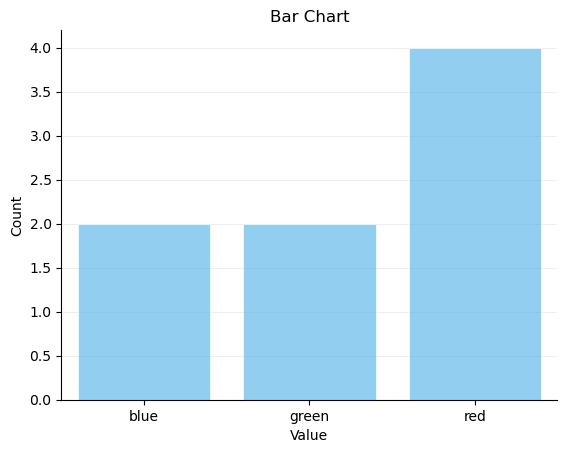

In [3]:
ax = plt.gca()
make_bar(colors, ax, SKY_BLUE, normalize=False)
plt.show()

## 3. Discrete numbers — one bar per value, no binning

For discrete numeric data, every distinct value gets its own bar. Because values are
placed as evenly spaced categories (not on a numeric axis), a bar chart never merges
neighboring values the way a histogram's bins can — which is exactly why it is offered
as an alternative to the histogram for discrete data.

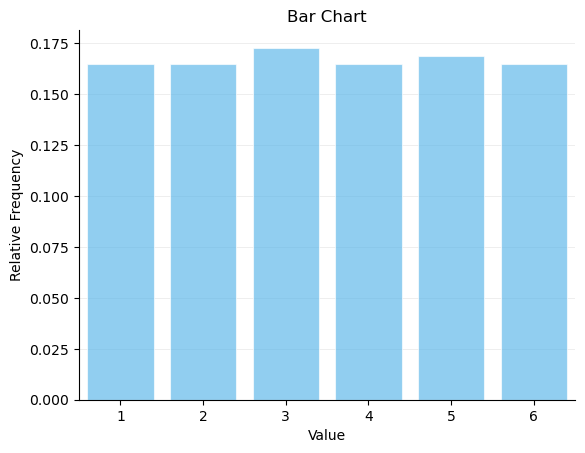

In [4]:
die = np.array([1, 2, 3, 4, 5, 6] * 40 + [3, 3, 5])  # six faces, 3 and 5 a bit heavier

ax = plt.gca()
make_bar(die, ax, SKY_BLUE)
plt.show()  # six bars labeled 1..6

## 4. Options: transparency and user overrides

`alpha` defaults to `BAR_ALPHA` (0.65), matching the histogram; an explicit value wins.
The white edge color and bar width are applied with `setdefault`, so a user's own
`edgecolor=` / `linewidth=` / `width=` keyword still takes precedence.

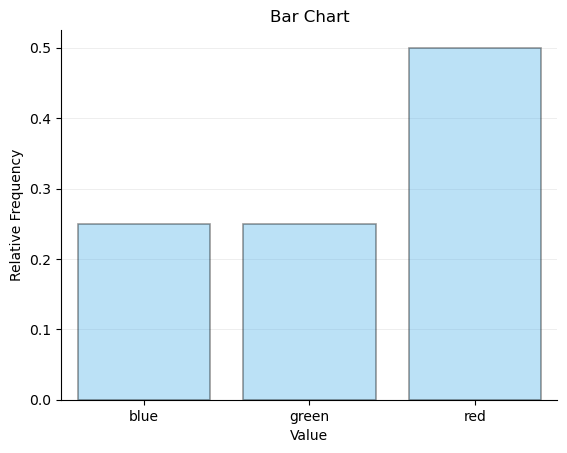

In [5]:
ax = plt.gca()
make_bar(colors, ax, SKY_BLUE, alpha=0.4, edgecolor="black", linewidth=1.2)
plt.show()

## 5. Overlay behavior — a grouped bar chart

In the final integration each `.plot()` call takes its color from `get_next_color(ax)`.
Overlaying two bar charts produces a **grouped bar chart**: the two series' bars are
**dodged side by side within each category** (together spanning `BAR_WIDTH`) rather than
drawn on top of one another, so no bar hides another. The distinct values are unioned
into one shared, sorted axis, light **vertical separator lines** mark the boundary
between neighboring categories, and a legend appears **automatically in the top right**,
auto-named "Variable 1", "Variable 2", ... A single bar chart takes the full category
width, with no separators and no legend.

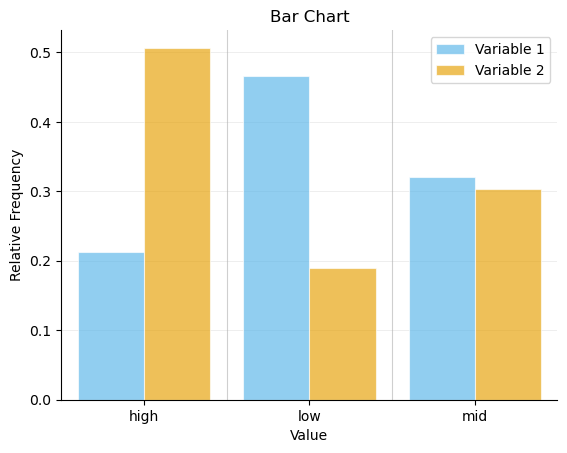

In [6]:
rng = np.random.default_rng(7)
group_a = rng.choice(["low", "mid", "high"], size=300, p=[0.5, 0.3, 0.2])
group_b = rng.choice(["low", "mid", "high"], size=300, p=[0.2, 0.3, 0.5])

ax = plt.gca()
make_bar(group_a, ax, get_next_color(ax))
make_bar(group_b, ax, get_next_color(ax))  # legend appears on this call
plt.show()

`label=` overrides the automatic "Variable k" names.

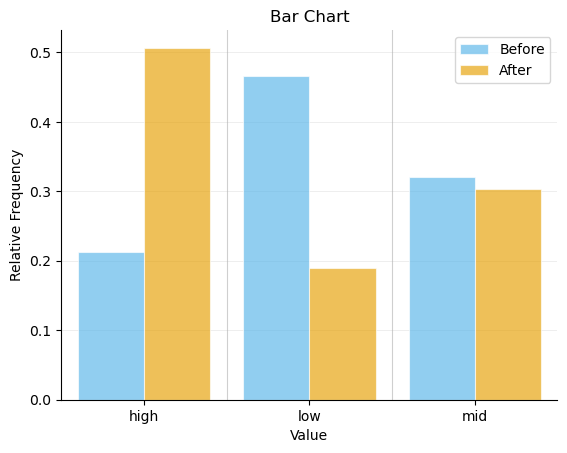

In [7]:
ax = plt.gca()
make_bar(group_a, ax, get_next_color(ax), label="Before")
make_bar(group_b, ax, get_next_color(ax), label="After")
plt.show()

## 6. Integrated into `.plot()`

`make_bar` is wired into `RVResults.plot()`, so `type="bar"` produces a real bar chart —
it is **no longer an alias for the histogram**. On discrete numeric data this gives one
bar per value straight from a simulation.

Passing `type="bar"` explicitly still prints the suggestion note, which now lists the
bar chart as the shown type and names the automatic default and the other alternatives.

Currently Showing: Bar Chart
Alternative Plots: Impulse Plot (Default), Histogram (type = "hist"), Dot Plot (type = "dotplot"), ECDF Plot (type = "ecdf")


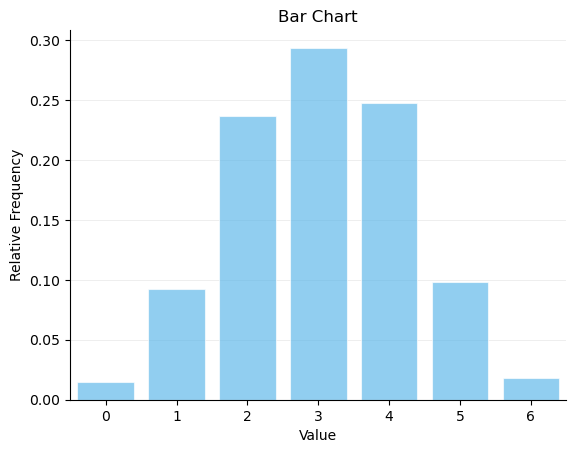

In [8]:
RV(Binomial(n=6, p=0.5)).sim(2000).plot(type="bar")
plt.show()  # title "Bar Chart"; note the suggestion message printed below

When you don't pass `type=`, a discrete RV defaults to an impulse plot and the
suggestion note lists the bar chart as one of the alternatives you can switch to with
`type="bar"`.

Currently Showing: Impulse Plot (Default)
Alternative Plots: Bar Chart (type = "bar"), Histogram (type = "hist"), Dot Plot (type = "dotplot"), ECDF Plot (type = "ecdf")


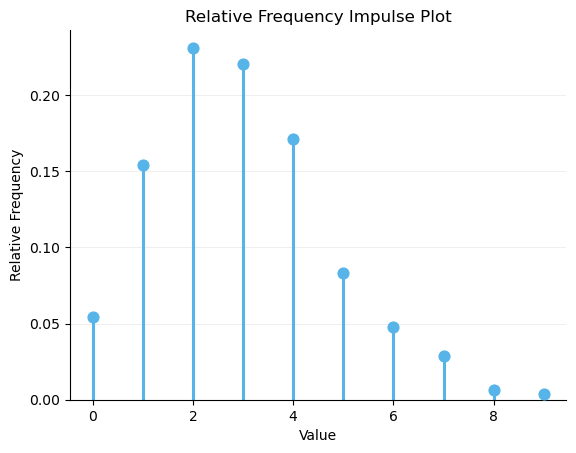

In [9]:
RV(Poisson(3)).sim(2000).plot(suggest=True)  # default impulse; bar offered as an alternative
plt.show()

### A note on categorical (string) RVs

`make_bar` itself handles string categories (Section 1). Reaching it through
`RV(...).sim(...).plot(type="bar")` for *string-valued* RVs is still blocked upstream:
a string RV currently gets `dim=None`, so `.plot()` skips the 1D dispatch entirely. That
is a separate change to the dimension logic in `RVResults`, not to the bar chart. For
now, plot categorical strings by calling `make_bar` directly, as in Section 1.

## Verification checklist

- [ ] One bar per distinct value; values never binned
- [ ] Categories placed in sorted order (numbers ascending, strings alphabetical),
  labeled with the value
- [ ] `normalize=True` heights sum to 1; `normalize=False` gives integer counts and a
  "Count" y-label
- [ ] x-axis reads "Value"; title reads "Bar Chart"
- [ ] White bar edges; horizontal grid behind the bars; no top/right spines
- [ ] `alpha` defaults to 0.65; explicit `alpha=` wins; user `edgecolor=`/`width=` win
- [ ] Single bar chart takes the full category width; no legend, no separators
- [ ] Overlaid charts are dodged side by side within each category (grouped bar chart),
  in distinct Okabe-Ito hues, over a shared sorted axis of every distinct value
- [ ] Vertical separator lines appear between categories once charts overlay
- [ ] Second overlaid chart adds an auto-numbered legend; `label=` overrides the names
- [ ] `type="bar"` in `.plot()` produces a bar chart (title "Bar Chart"), not a histogram
- [ ] The suggestion message offers `type="bar"` as an alternative for discrete data